# MeRN Quick Start Tutorial

## Metabolic Representation Net (MeRN)

Single-cell RNA-seq data provides rich information about gene expression across thousands of cells, but interpreting **cellular metabolism** from transcriptomic data alone is challenging. Many metabolic processes are coordinated across genes and reactions, making them difficult to capture with standard dimensionality reduction methods.

**Metabolic Representation Net (MeRN)** is a graph-guided variational autoencoder designed to infer metabolic state from single-cell transcriptomic data.

Standard VAEs such as **scVI** learn low-dimensional latent representations of cells and decode them to gene-level parameters using flexible neural networks. While these models capture complex transcriptional structure, the latent dimensions are not explicitly linked to metabolic processes.

MeRN introduces a **metabolic prior** by leveraging a metabolic reaction graph, where:

- **nodes** represent metabolic reactions  
- **edges** connect reactions that share metabolites

A graph VAE learns embeddings of this reaction network, and the cell-level latent space is decomposed into two components:

• **Metabolic variation**: variation explained by metabolic reactions  
• **Non-metabolic variation**: transcriptomic variation explained by genes not encoding enzymes

This structure links latent dimensions to **reaction activity and enzyme-coding genes**, enabling interpretable metabolic representations.

In this tutorial, we apply MeRN to a mouse embryogenesis single-cell RNA-seq dataset. We will:

1. Load the preprocessed wild-type embryogenesis dataset.
2. Fit or load a pretrained MeRN model.
3. Extract metabolic and non-metabolic latent spaces.
4. Analyze the metabolic latent space with UMAP and clustering.
5. Decode reaction-level enzyme activity.
6. Aggregate reaction activity into KEGG pathway scores.
7. Build data-driven pathways (DDPs), which group graph-connected reactions with coordinated activity across cells.
8. Compare reaction, KEGG pathway, and DDP activity across metabolic clusters.
9. Visualize glycolysis/gluconeogenesis on KEGG pathway graphs, colored by DDP membership and by differential reaction activity.
10. Expand a KEGG pathway by plotting all reactions in DDPs connected to glycolysis.
11. Compare DDP structure between wild-type and *Folr1* knockout embryos in a matched metabolic
    state. Steps 1-10 use the wild type alone; the knockout enters only as a table of decoded
    reaction activity.

The tutorial emphasizes DDPs as a data-driven interpretation layer between individual reactions and broad canonical pathways. Reactions are highly granular, while KEGG pathways are predefined and often broad. DDPs provide coordinated metabolic reaction programs learned from the data and constrained by the metabolic graph.

In [1]:
# TO-DO: ZENODO SCRIPT

TO-DO: List Files Required and Folder File Structure

In [2]:
from scvi.train._callbacks import SaveCheckpoint
from mern import MERN
import mern.support as mern_support
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import os
import plotly.colors as pc
from contextlib import contextmanager

/opt/homebrew/Caskroom/miniforge/base/envs/mern_skin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Set Parameters
train_new_model = False
clustering_res = 0.4
chosen_rep = 0      # replicate used for the latent spaces and UMAPs shown below
n_reps = 10         # replicates to load; enzyme activity is averaged across all of them

base_path = ".."
base_path_data = f'{base_path}/data/embryogenesis'
base_path_model = f'{base_path}/models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1'
folr1_path_model = f'{base_path}/models/embryogenesis/folr1_main_kl_search_25/max_kl_0.001_graph_kl_0.1'

wt_adata_file = 'main_wt_anndata_pp.h5ad.gz'

suffix = f'_rep{chosen_rep}'
metabolic_key = f"X_mern_metabolic{suffix}"
background_key = f"X_mern_background{suffix}"
metabolic_umap_key = f"X_umap_metabolic{suffix}"
background_umap_key = f"X_umap_background{suffix}"
graph_key = f"graph{suffix}"

### Figure Colors

A small color registry keeps the figures in this tutorial consistent: one fixed color per DDP,
fixed colors for genotype and cell-cycle phase, and vector-friendly font settings so exported PDFs
keep their text editable.

`EMBRYO_DDP_PALETTE` assigns a stable color to each of the 24 DDPs shown in the cross-genotype
comparison at the end. Any DDP outside that set — including the whole-dataset DDPs built in the next
section, which use a different threshold and cell population — falls back to Plotly's Dark24, the
sequence the registry was drawn from.

In [4]:
TEXT_COLOR = '#222222'
STRUCTURE_COLOR = '#666666'    # dendrogram links, outlines
BACKGROUND_COLOR = '#A7ADB8'   # de-emphasized points
MISSING_COLOR = '#CFCFCF'      # "not assigned"
OBSERVED_COLOR = '#0072B2'     # the MeRN measurement itself
HIGHLIGHT_COLOR = '#D55E00'    # the one feature a figure is about

METHOD_PALETTE = {
    'mern': '#0072B2',
    'rna': '#E69F00',
    'scrna': '#009E73',
    'prot': '#222222',
    'kegg_metroscreen': '#CC79A7',
    'compass': '#56B4E9',
}

GENOTYPE_PALETTE = {
    'WT': '#7A7A7A',
    'Folr1': '#8C6BB1',
    'Folr1 KO': '#8C6BB1',
}

# Germ layers of the embryo proper, in this dataset's color scheme.
GERMLAYER_PALETTE = {
    'Epiblast': '#000000',
    'PrimitiveStreak': '#808080',
    'GermCell': '#DB083D',
    'Endoderm': '#F5F200',
    'XMesoderm': '#00C4ED',
    'AxialMesoderm': '#0000FC',
    'Mesoderm': '#910299',
    'NeuralEctoderm': '#008C2A',
    'NonNeuralEctoderm': '#334513',
}

PHASE_PALETTE = {
    'G0/G1': '#4C78A8',
    'S': '#F2CF5B',
    'G2': '#72B7B2',
    'M': '#B279A2',
}

HEATMAP_CMAP = mpl.colormaps['viridis']

# Plotly Dark24, keyed explicitly so each of the 24 DDPs below keeps a unique, stable color.
EMBRYO_DDP_PALETTE = {
    'ddp_3': '#2E91E5',
    'ddp_32': '#E15F99',
    'ddp_37': '#1CA71C',
    'ddp_44': '#FB0D0D',
    'ddp_46': '#DA16FF',
    'ddp_53': '#222A2A',
    'ddp_58': '#B68100',
    'ddp_59': '#750D86',
    'ddp_66': '#EB663B',
    'ddp_83': '#511CFB',
    'ddp_89': '#00A08B',
    'ddp_90': '#FB00D1',
    'ddp_91': '#FC0080',
    'ddp_92': '#B2828D',
    'ddp_94': '#6C7C32',
    'ddp_100': '#778AAE',
    'ddp_103': '#862A16',
    'ddp_111': '#A777F1',
    'ddp_113': '#620042',
    'ddp_116': '#1616A7',
    'ddp_118': '#DA60CA',
    'ddp_123': '#6C4516',
    'ddp_124': '#0D2A63',
    'ddp_127': '#AF0038',
}


def reset_plotting_defaults():
    """Editable-text vector output and a consistent typeface."""
    mpl.rcdefaults()
    sns.reset_defaults()
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'axes.spines.top': False,
        'axes.spines.right': False,
        'legend.frameon': False,
        'figure.dpi': 150,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
    })


reset_plotting_defaults()


def styled_theme(**kwargs):
    """`sns.set_theme` that keeps this tutorial's typeface and editable-text vector output."""
    kwargs.setdefault('font', 'Arial')
    rc = {
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',
        'legend.frameon': False,
    }
    rc.update(kwargs.pop('rc', {}))
    sns.set_theme(rc=rc, **kwargs)


def ddp_palette_sequence(labels):
    """Colors for a set of DDP labels: the registry first, Dark24 for the rest.

    Unregistered DDPs take Dark24 colors the registry has not already claimed, so a DDP set that
    mixes the two does not reuse one color for two pathways.
    """
    categories = list(pd.Series(labels).dropna().unique())
    claimed = {EMBRYO_DDP_PALETTE[c] for c in categories if c in EMBRYO_DDP_PALETTE}
    spare = [c for c in pc.qualitative.Dark24 if c not in claimed] or list(pc.qualitative.Dark24)

    sequence, next_spare = [], 0
    for label in categories:
        if label in EMBRYO_DDP_PALETTE:
            sequence.append(EMBRYO_DDP_PALETTE[label])
        else:
            sequence.append(spare[next_spare % len(spare)])
            next_spare += 1
    return sequence


def ddp_color_map_for(labels):
    """DDP label -> color, for the `ddp_color_map` argument of the pathway plots."""
    categories = list(pd.Series(labels).dropna().unique())
    return dict(zip(categories, ddp_palette_sequence(categories)))


@contextmanager
def ddp_pathway_palette(labels):
    """The pathway plots color discrete edge labels from Plotly's Set1, in order of first
    appearance. Swap the DDP registry in for the duration of one plot."""
    original = pc.qualitative.Set1
    pc.qualitative.Set1 = ddp_palette_sequence(labels)
    try:
        yield
    finally:
        pc.qualitative.Set1 = original

### Loading the WT Dataset

The wild-type data is read from `main_wt_anndata_pp.h5ad.gz` (62,433 cells x 19,548 genes), the
preprocessed object the pretrained models were trained on. Cells outside the embryo proper (the
`Blood&Vas`, `XEctoderm`, and `XEndoderm` germ layers) and genes detected in fewer than 100 cells
have already been removed, so no further preprocessing is needed here.

The feature space is the object's own `highly_variable_metabolic` / `highly_variable_background`
flags, sorted — 800 metabolic plus 5,000 non-metabolic genes. A MeRN model only loads onto the feature
space it was trained on, so the cell after the loader checks that match rather than assuming it. The
full-gene object is kept as `rna_full` for expression-level views.

`X` is already log1p-normalized; `layers['counts_RNA']` holds the raw counts the model reads.

In [5]:
rna_full = ad.read_h5ad(f'{base_path_data}/{wt_adata_file}')

dataset = mern_support.KeggKGMLMetabolicDataset(species='mouse', capitalize=False)
dataset.add_module_info(rna_full)

# The model's feature space: the HVG flags stored in the object, sorted.
features_to_use = sorted(
    rna_full.var_names[
        rna_full.var['highly_variable_metabolic'] | rna_full.var['highly_variable_background']
    ]
)
rna = rna_full[:, features_to_use].copy()

# The graph and the reaction -> gene mapping are built on the feature space the model saw.
met_g = dataset.metabolic_topology(rna, self_loops=False)
dataset.add_rxn_module_info(rna, met_g)
dataset.add_rxn_module_info(rna_full, met_g)
rxn_genes = dataset.get_rxn_genes_all()

# X is already log1p-normalized; only `rna` still needs the raw counts the model reads.
del rna_full.layers['counts_RNA']
rna_full.layers['log1p_norm'] = rna_full.X
rna.layers['log1p_norm'] = rna.X

rxn_info = rna.uns["Reaction Info"]
rxn_ids = rxn_info.index.to_list()

print(rna)
print(rna.var['Metabolic Gene'].value_counts())

AnnData object with n_obs × n_vars = 62433 × 5800
    obs: 'nCount_RNA', 'nFeature_RNA', 'log_count', 'percent.mt', 'sex', 'embryo_id', 'sample_group', 'timepoint', 'cell_type', 'germlayer'
    var: 'names', 'n_cells', 'Gene Reactions', 'Metabolic Gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_metabolic', 'highly_variable_background'
    uns: 'hvg', 'Reaction Info'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts_RNA', 'log1p_norm'
Metabolic Gene
Non-metabolic    5000
Metabolic         800
Name: count, dtype: int64


In [6]:
# Make the identity columns categorical so category order - and therefore color order - is stable.
# Germ layers get the palette defined above; `cell_type` has too many categories for a hand-built
# palette, so scanpy assigns those colors itself.
for adata_obj in [rna, rna_full]:
    for col in ('cell_type', 'germlayer'):
        if col in adata_obj.obs:
            adata_obj.obs[col] = adata_obj.obs[col].astype('category')

    if 'germlayer' in adata_obj.obs:
        adata_obj.uns['germlayer_colors'] = [
            GERMLAYER_PALETTE.get(cat, MISSING_COLOR)
            for cat in adata_obj.obs['germlayer'].cat.categories
        ]

### Loading or Training a MeRN Model
You can either train a fresh MeRN model (or load a saved checkpoint). When training, set loss weights and KL schedules, configure checkpointing, and fit the model with early stopping. After training, reload the best checkpoint, save the training history, and plot key loss curves to verify convergence. If not training, load the pretrained model and history, then re-instantiate the MeRN model with the chosen architecture.

TODO: generally we train multiple models (10 models 8 decodes?)

In [7]:
if train_new_model:
    data_dir = 'models'

    plan_kwargs={
        "max_kl_weight": 0.001,
        "graph_kl_weight": 0.1,
        "data_elbo_weight": 1.0,
        "graph_elbo_weight": 0.2,
        "rxn_genes_weight": 0.5,
        "background_to_metabolic_weight": 30000,
        "lr": 0.002,
        "n_steps_kl_warmup": 0,
        "n_epochs_kl_warmup": None
    }

    checkpointing = SaveCheckpoint(
        dirpath=f'{data_dir}/scvi_log_3', monitor="validation_loss", load_best_on_end=False, check_nan_gradients=False
    )
    MERN.setup_anndata(rna, layer='counts_RNA', batch_key=None)
    mern = MERN(rna, met_g, rxn_genes, n_hidden=256, n_layers=2, n_metabolic_dim=25, n_background_dim=15, encode_covariates=False, strict_met_back_separation=True, rxn_genes_bias=True)
    mern.train(accelerator="mps", max_epochs=400, early_stopping=True, early_stopping_monitor="validation_loss", plan_kwargs=plan_kwargs, callbacks = [checkpointing])

    best_mern = MERN.load(checkpointing.best_model_path, rna, accelerator='mps')
else:
    # Enzyme activity is averaged across replicates, so load them all. `MERN.load` checks each model
    # against the feature space it was trained on, so a mismatch fails here rather than silently.
    models_by_rep = {}
    for rep in range(n_reps):
        try:
            models_by_rep[rep] = MERN.load(
                f'{base_path_model}/mern_rep_{rep}', rna, accelerator='cpu'
            )
        except Exception as error:
            print(f'replicate {rep} unavailable ({type(error).__name__})')

    if chosen_rep not in models_by_rep:
        raise RuntimeError(f'replicate {chosen_rep} is required for the embeddings below')

    models = list(models_by_rep.values())
    mern = models_by_rep[chosen_rep]
    print(f'{len(models)} of {n_reps} replicates loaded')


INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1/mern_rep_0/model.pt already   
         downloaded                                                                                                


INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1/mern_rep_1/model.pt already   
         downloaded                                                                                                
INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1/mern_rep_2/model.pt already   
         downloaded                                                                                                
INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1/mern_rep_3/model.pt already   
         downloaded                                                                                                
INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_graph_kl_0.1/mern_rep_4/model.pt already   
         downloaded                                                                                                
INFO     File ../models/embryogenesis/wt_main_kl_search_25/max_kl_0.001_

### Extracting the Embeddings

The model maps every cell into two latent spaces at once — a metabolic one tied to the reaction
graph, and a non-metabolic one for variation not explained through that graph — and every reaction into a graph embedding.
`get_latent_representation` returns all three. It reports the mean of each latent distribution, so
repeated calls give identical answers.

In [8]:
metabolic_latent, background_latent, graph_embedding = mern.get_latent_representation(rna)

rna.obsm[metabolic_key] = metabolic_latent
rna.obsm[background_key] = background_latent
rna.uns[graph_key] = pd.DataFrame(graph_embedding, index=mern.vertex_names_ordered)

print(f'metabolic latent : {metabolic_latent.shape[0]:,} cells x {metabolic_latent.shape[1]} dims')
print(f'non-metabolic latent: {background_latent.shape[0]:,} cells x {background_latent.shape[1]} dims')
print(f'graph embedding  : {graph_embedding.shape[0]:,} reactions x {graph_embedding.shape[1]} dims')

metabolic latent : 62,433 cells x 25 dims
non-metabolic latent: 62,433 cells x 15 dims
graph embedding  : 1,213 reactions x 25 dims


## Metabolic and Non-Metabolic Latent Spaces

MeRN learns two latent embeddings for each cell:

### Non-metabolic latent space

The non-metabolic latent space captures transcriptomic variation explained by genes not encoding enzymes.

### Metabolic latent space

The metabolic latent space captures variation that is routed through the metabolic reaction graph. Cells that are transcriptionally similar can still separate in this space if they differ in inferred reaction activity or coordinated metabolic programs.

This latent space is the main space we use to identify metabolic cell states.

By comparing the metabolic and non-metabolic latent spaces, we can ask whether differences between cells are better explained by:

- non-metabolic transcriptional variation
- metabolic reaction-level variation

In the next cells, we compute neighborhoods, UMAPs, and clusters separately for the metabolic and non-metabolic latent spaces.

### Embedding Clustering

/var/folders/rw/56p7h0px0xl82phr2ps3qy8c0000gn/T/ipykernel_11764/2053381414.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)


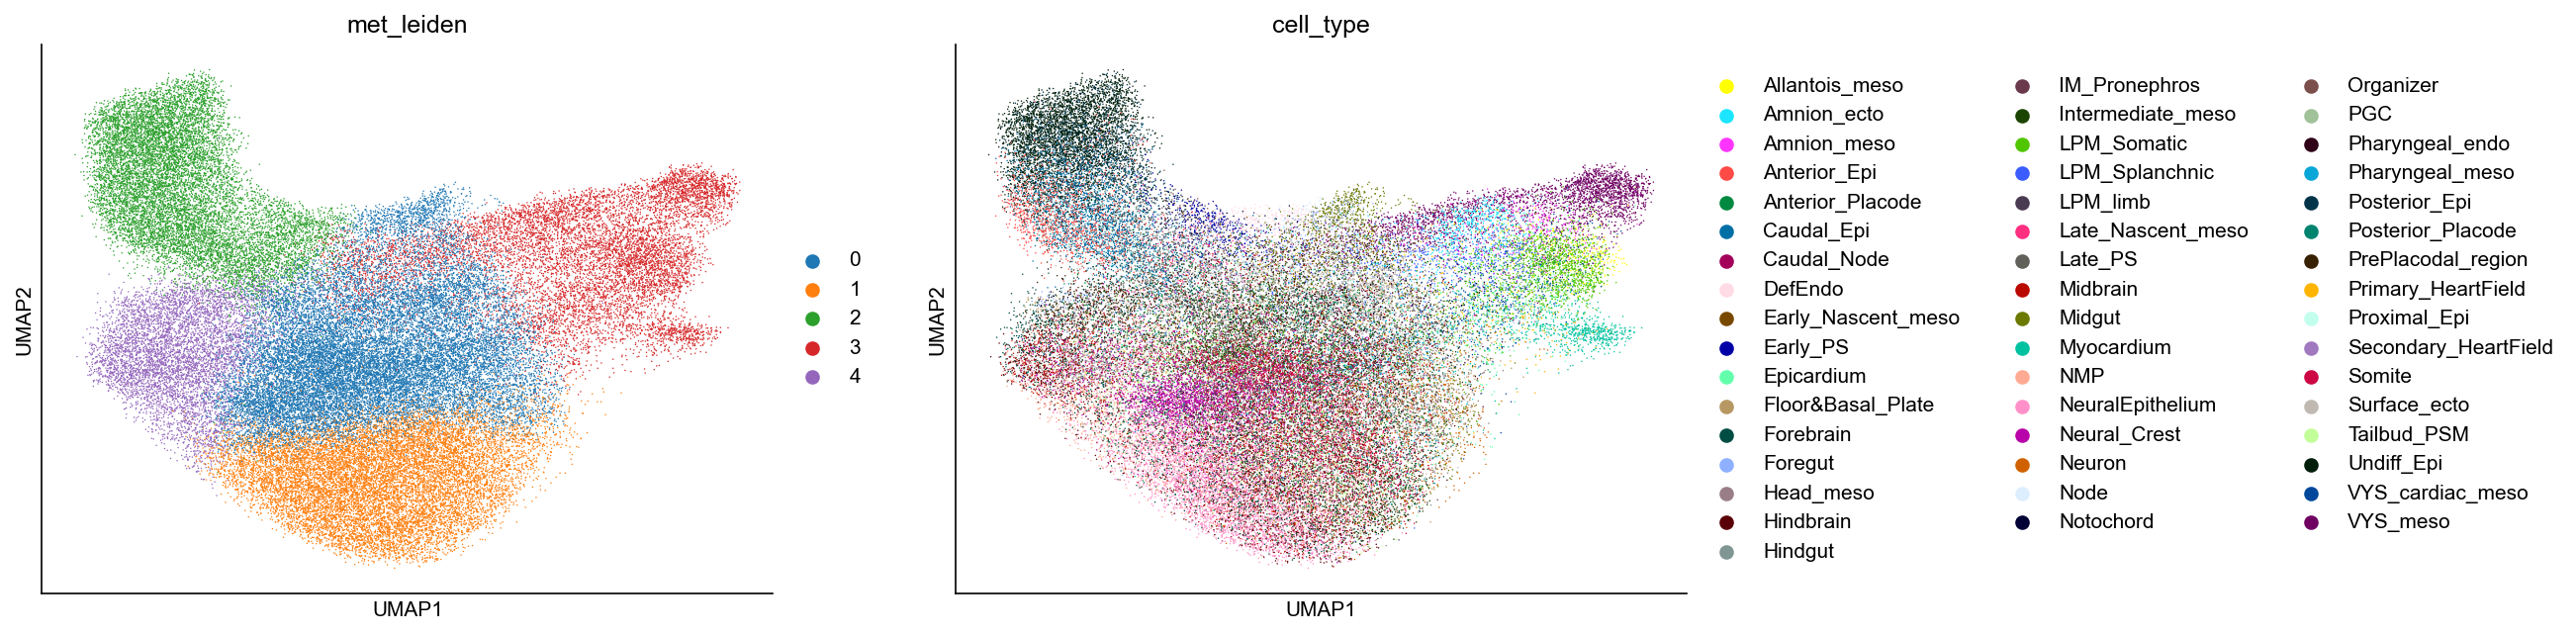

In [9]:
# metabolic embedding
sc.pp.neighbors(rna, use_rep=metabolic_key, key_added='met_neighbors')
sc.tl.umap(rna, neighbors_key='met_neighbors')
sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['met_leiden', 'cell_type'], neighbors_key='met_neighbors')

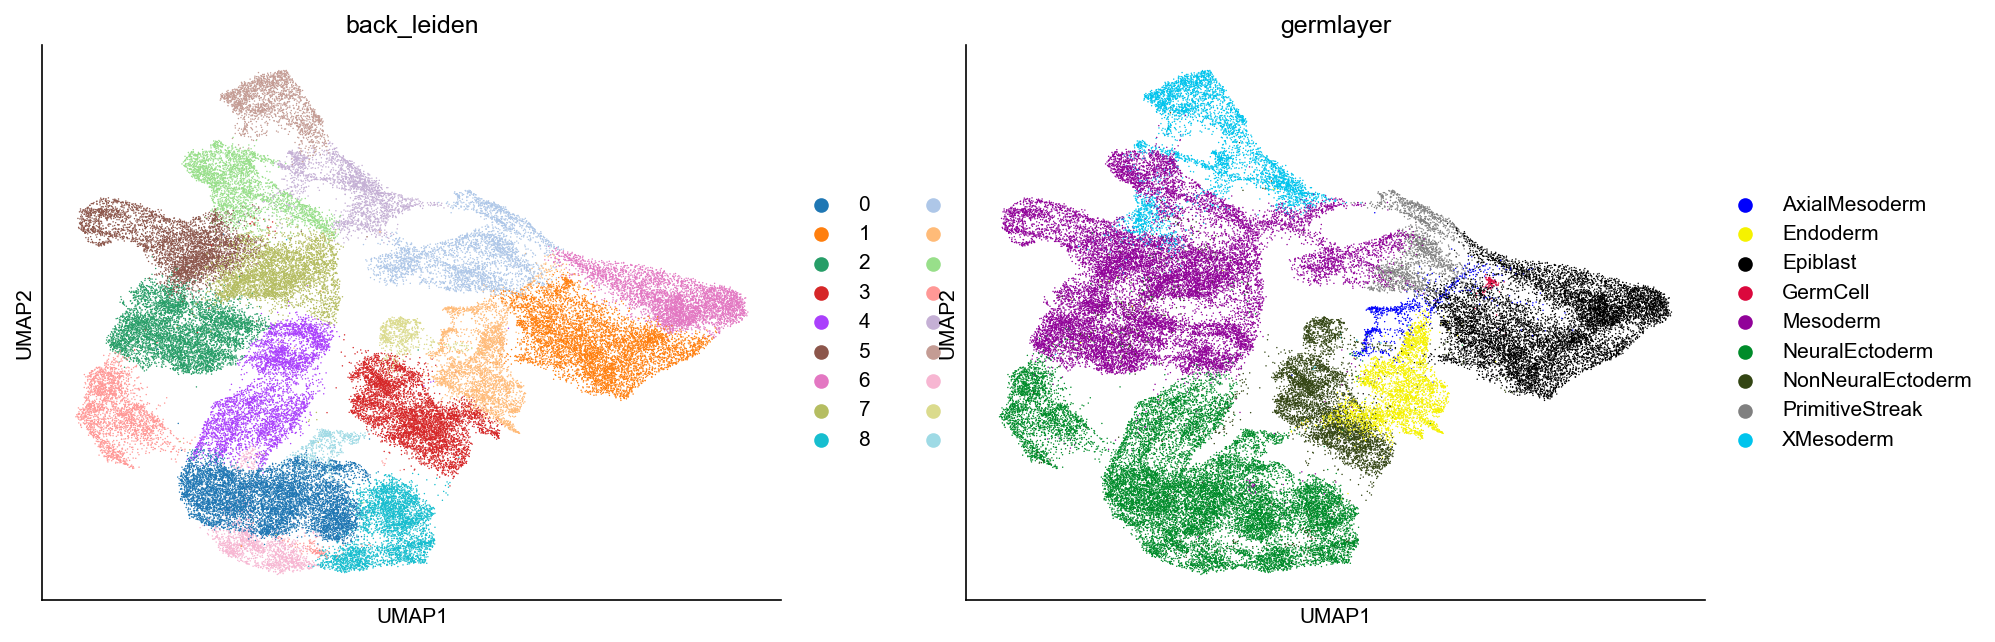

In [10]:
# Non-metabolic latent space (the public API retains the background_key name).
sc.pp.neighbors(rna, use_rep=background_key, key_added='back_neighbors')
sc.tl.umap(rna, neighbors_key='back_neighbors')
sc.tl.leiden(rna, neighbors_key='back_neighbors', key_added='back_leiden', resolution=clustering_res)
sc.pl.umap(rna, color=['back_leiden', 'germlayer'], neighbors_key='back_neighbors')

### Metabolic Embedding Analysis

We cluster cells in the MeRN metabolic embedding to identify metabolic states. To relate these states to embryonic development, we plot the proportion of cells in each metabolic cluster across timepoints.

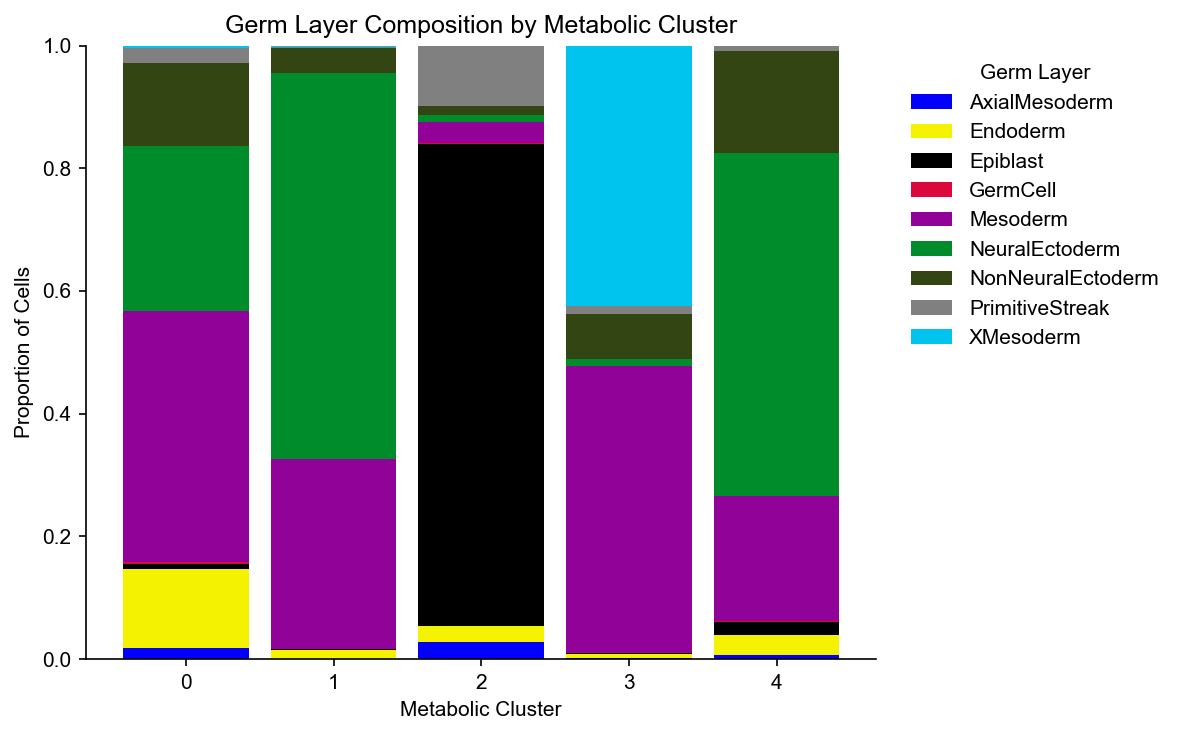

In [11]:
cluster_key = "met_leiden"
group_key = "germlayer"

rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[cluster_key],
    rna.obs[group_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

germlayer_order = list(rna.obs[group_key].cat.categories)
props = props.reindex(columns=germlayer_order, fill_value=0)

colors = [
    GERMLAYER_PALETTE.get(germlayer, MISSING_COLOR)
    for germlayer in germlayer_order
]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Metabolic Cluster")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Germ Layer Composition by Metabolic Cluster")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Germ Layer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

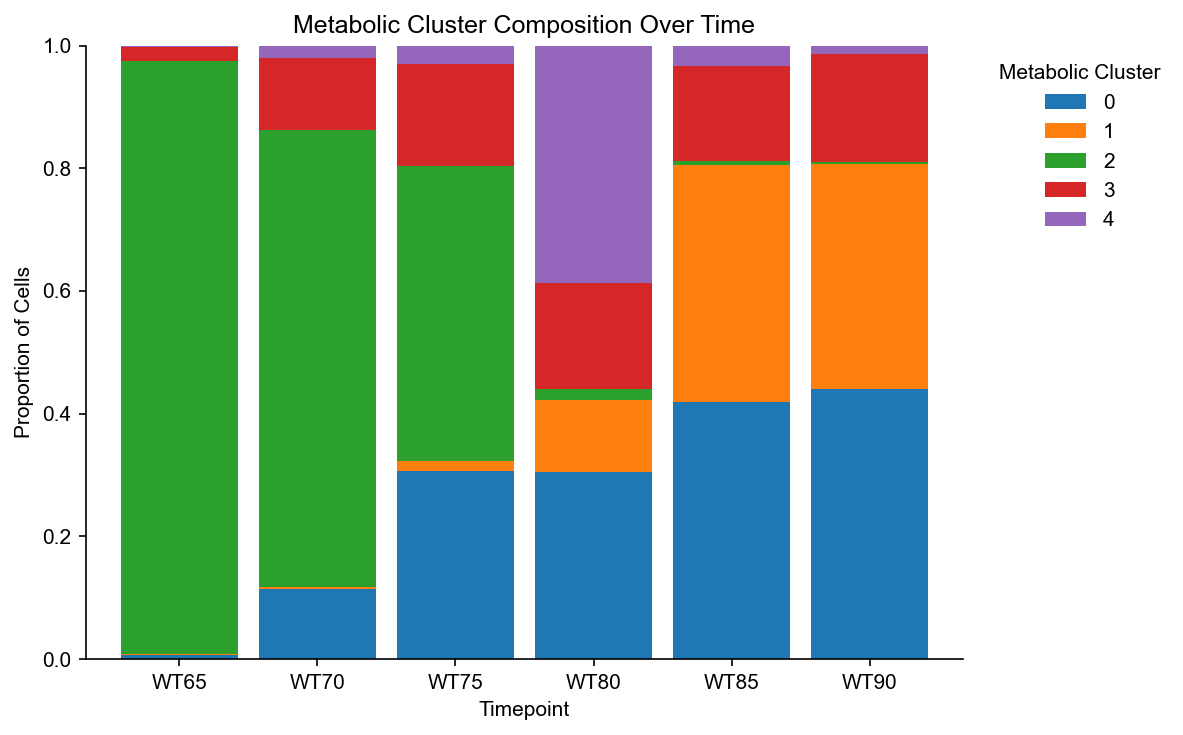

In [12]:
time_key = "timepoint"
cluster_key = "met_leiden"

rna.obs[time_key] = rna.obs[time_key].astype(str).astype("category")
rna.obs[cluster_key] = rna.obs[cluster_key].astype(str).astype("category")

counts = pd.crosstab(
    rna.obs[time_key],
    rna.obs[cluster_key],
)

props = counts.div(counts.sum(axis=1), axis=0)

cluster_order = sorted(
    rna.obs[cluster_key].cat.categories,
    key=lambda x: int(x) if str(x).isdigit() else str(x),
)

props = props.reindex(columns=cluster_order, fill_value=0)

cluster_palette = dict(
    zip(
        cluster_order,
        sns.color_palette("tab10", n_colors=len(cluster_order)).as_hex(),
    )
)

colors = [cluster_palette[c] for c in cluster_order]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(8, 5),
    width=0.85,
    edgecolor="none",
)

ax.set_xlabel("Timepoint")
ax.set_ylabel("Proportion of Cells")
ax.set_title("Metabolic Cluster Composition Over Time")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Metabolic Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

## Enzyme Activity, Data-Driven Pathway, and KEGG Pathway Calculations

MeRN provides reaction-level enzyme activity for each cell. From this reaction activity matrix, we can compute two additional metabolic summaries: data-driven pathways (DDPs) and KEGG pathway scores.

This gives three activity matrices that we use throughout the rest of the tutorial:

1. **Enzyme activity**: cells × reactions
2. **DDP activity**: cells × data-driven pathways
3. **KEGG pathway activity**: cells × canonical KEGG pathways

### Decoding Enzyme Activity

Reaction-level enzyme activity is the decoded output the rest of this tutorial analyses: a
cells x reactions matrix giving the activity MeRN infers for each reaction in each cell.

It is a **sampled** quantity. Each decode draws from the model's posterior, so two decodes of the
same cells differ — and separately trained replicates differ from each other too.
`mern_support.average_enzyme_activity` averages over both: `n_samples` decodes per model, across
however many replicates you pass it.

Decoding every cell from every replicate takes a few minutes, so the demonstration below uses a
subset of cells. The analysis afterwards uses the full precomputed table.

In [13]:
demo_cells = rna.obs_names[:5_000]
demo = rna[demo_cells].copy()

# One decode, from one replicate.
one_draw = mern_support.average_enzyme_activity([mern], demo, n_samples=1, show_progress=False)

print('one decode:', f'{one_draw.shape[0]:,} cells x {one_draw.shape[1]:,} reactions')
display(one_draw.iloc[:4, :3])

Seed set to 8


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
one decode: 5,000 cells x 1,213 reactions


,rn:R00351 rn:R00352,rn:R00209 rn:R00212 rn:R01196 rn:R10866,rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R00726
WT65_1_TACACCCTCGGCTGGT-1,0.00000,5.039643,1.120782
WT65_1_AGTCACACACGAAAGC-1,0.00000,5.660320,0.600536
WT65_1_GGAAGTGTCCAAACCA-1,1.26934,7.724673,2.693870
WT65_1_CATTGCCTCCCTGGTT-1,0.00000,7.369741,0.495612


How much does one draw vary? Decoding the same cells again with a different seed gives an
independent draw, and comparing the two shows how much of a single decode is sampling noise.

Seed set to 99


rn:R04209: correlation between two decodes = 0.268
median across all reactions                 = 0.281


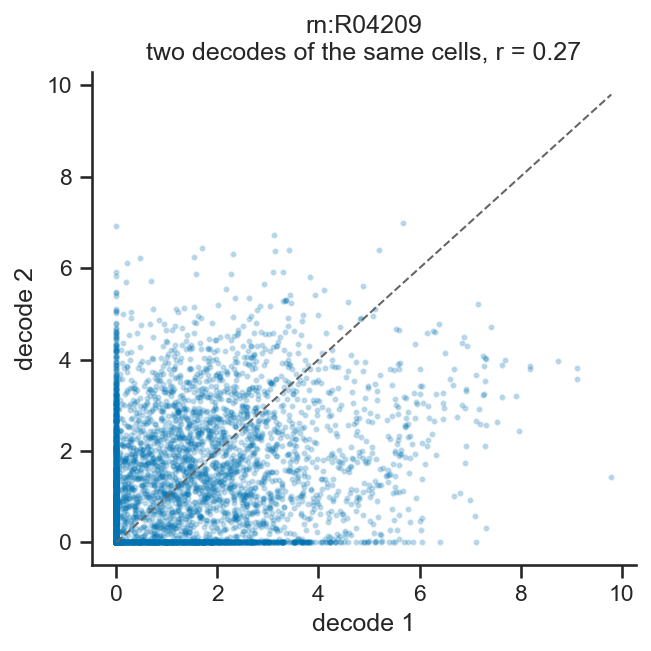

In [14]:
# Decode the same cells again from the same model: an independent draw.
second_draw = mern_support.average_enzyme_activity(
    [mern], demo, n_samples=1, seed=99, show_progress=False
)

example_rxn = 'rn:R04209'   # AIR carboxylation
draw_corr = one_draw[example_rxn].corr(second_draw[example_rxn])
print(f'{example_rxn}: correlation between two decodes = {draw_corr:.3f}')
print(f'median across all reactions                 = {one_draw.corrwith(second_draw).median():.3f}')

styled_theme(style='ticks', context='notebook')
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(one_draw[example_rxn], second_draw[example_rxn],
           s=4, alpha=0.2, color=OBSERVED_COLOR, rasterized=True)
lims = (0, max(one_draw[example_rxn].max(), second_draw[example_rxn].max()))
ax.plot(lims, lims, color=STRUCTURE_COLOR, linewidth=1, linestyle='--')
ax.set_xlabel('decode 1'); ax.set_ylabel('decode 2')
ax.set_title(f'{example_rxn}\ntwo decodes of the same cells, r = {draw_corr:.2f}')
sns.despine(fig); fig.tight_layout(); plt.show()

Averaging across the replicates removes most of that variability, and taking several samples per
replicate removes a little more. The table below compares the spread of each estimate.

In [15]:
across_reps = mern_support.average_enzyme_activity(
    models, demo, n_samples=1, show_progress=False
)
print(f'averaged one decode from each of {len(models)} replicates')

Seed set to 8
Seed set to 1008


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Seed set to 2008


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Seed set to 3008


...

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Seed set to 8008


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Seed set to 9008


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
averaged one decode from each of 10 replicates


A single decode is largely noise, and that matters downstream: DDPs are built by thresholding
reaction-reaction correlations, so noise in the activity estimate weakens every correlation and
fewer reactions clear the cutoff.

The analysis below therefore uses a decode averaged over **all ten replicates, eight samples each** -
the same `average_enzyme_activity` call, scaled up. Because that is eighty decodes, it is provided
precomputed rather than run here:

```python
mern_support.average_enzyme_activity(models, rna, n_samples=8)   # ~80 decodes
```

In [16]:
enzyme_acts_mean = pd.read_csv(f'{base_path_model}/average_enzyme_activity.csv.gz', index_col=0)

# The precomputed table must line up with the cells and reactions in this session.
assert enzyme_acts_mean.index.equals(rna.obs_names), 'activity table does not match these cells'
assert enzyme_acts_mean.columns.equals(one_draw.columns), 'activity table has different reactions'

spread = pd.DataFrame({
    '1 replicate x 1 sample': one_draw.std(),
    f'{len(models)} replicates x 1 sample': across_reps.std(),
    'provided (10 replicates x 8 samples)': enzyme_acts_mean.loc[demo_cells].std(),
}).median().round(3)
print('median spread across reactions:')
print(spread.to_string())
print()
print('analysis uses:', f'{enzyme_acts_mean.shape[0]:,} cells x {enzyme_acts_mean.shape[1]:,} reactions')

median spread across reactions:
1 replicate x 1 sample                  0.920
10 replicates x 1 sample                0.368
provided (10 replicates x 8 samples)    0.293

analysis uses: 62,433 cells x 1,213 reactions


### Calculating Data-Driven Pathways (DDPs)

DDPs are groups of reactions that are both connected in the metabolic reaction graph and coordinated across cells.

To construct DDPs, we:

1. Restrict to reactions present in both the enzyme activity matrix and the metabolic graph.
2. Remove reactions with no variation across cells.
3. Compute reaction-reaction correlations across cells.
4. Cluster graph-connected reactions using a minimum correlation threshold.
5. Score each cell for each DDP by averaging activity across member reactions.

The resulting `ddp_scores` matrix has cells as rows and DDPs as columns

In [17]:
ddp_min_corr = 0.7
ddp_min_size = 3

common_rxns = enzyme_acts_mean.columns.intersection(pd.Index(met_g.nodes()))

enzyme_acts_ddp = enzyme_acts_mean.loc[:, common_rxns].copy()

enzyme_acts_ddp = enzyme_acts_ddp.loc[:, enzyme_acts_ddp.std(axis=0) > 0].copy()

print("\nDDP construction input")
print("  cells x graph reactions:", enzyme_acts_ddp.shape)

corr_df = enzyme_acts_ddp.corr()

rxn_to_ddp, ddp_rxns, ddp_clusters, _ = mern_support.calculate_ddps(
    G=met_g,
    corr_df=corr_df,
    min_corr=ddp_min_corr,
    min_size=ddp_min_size,
)

print("\nDDPs")
print("  number of DDPs:", len(ddp_rxns))

ddp_sizes = pd.Series(
    {ddp: len(rxns) for ddp, rxns in ddp_rxns.items()},
    name="n_reactions",
)

display(ddp_sizes.describe())
display(ddp_sizes.sort_values(ascending=False).head(10))

ddp_scores, ddp_rxns = mern_support.calculate_ddp_scores(
    enzyme_acts=enzyme_acts_ddp,
    rxn_to_ddp=rxn_to_ddp,
)

print("\nDDP activity matrix")
print("  cells x DDPs:", ddp_scores.shape)


DDP construction input
  cells x graph reactions: (62433, 1213)

DDPs
  number of DDPs: 111


count    111.000000
mean      10.126126
std        9.565199
min        3.000000
25%        4.000000
50%        7.000000
75%       13.000000
max       49.000000
Name: n_reactions, dtype: float64

ddp_110    49
ddp_109    46
ddp_108    39
ddp_107    37
ddp_106    37
ddp_105    37
ddp_104    34
ddp_103    24
ddp_102    24
ddp_101    23
Name: n_reactions, dtype: int64


DDP activity matrix
  cells x DDPs: (62433, 111)


### Calculating KEGG Pathway Scores

We next aggregate MeRN's reaction-level enzyme activity into KEGG pathway scores.

The input `enzyme_acts` matrix contains cells as rows and metabolic reactions as columns. Using the reaction metadata in `rxn_info`, each reaction is mapped to one or more KEGG pathways. For each cell and each KEGG pathway, we calculate the average activity of the reactions assigned to that pathway.

This produces three outputs:

- `pathway_scores`: a cells × KEGG pathways matrix of pathway activity scores
- `pathway_rxns`: a dictionary mapping each KEGG pathway ID to its member reactions
- `pathway_names`: a dictionary mapping KEGG pathway IDs to readable pathway names

These pathway scores provide a canonical pathway-level view of metabolic activity, which we can compare with the reaction-level and DDP-level representations.

In [18]:
pathway_scores, pathway_rxns, pathway_names = mern_support.calculate_pathway_scores(
    enzyme_acts=enzyme_acts_mean,
    reaction_info=rxn_info
)

print("\nKEGG pathway activity matrix")
print("  cells x pathways:", pathway_scores.shape)

pathway_sizes = pd.Series(
    {pathway: len(rxns) for pathway, rxns in pathway_rxns.items() if pathway in pathway_scores.columns},
    name="n_reactions",
)

display(pathway_sizes.describe())
display(pathway_scores.head())



KEGG pathway activity matrix
  cells x pathways: (62433, 122)


count     122.000000
mean       30.229508
std       112.081197
min         1.000000
25%         4.000000
50%        14.000000
75%        27.000000
max      1213.000000
Name: n_reactions, dtype: float64

,rn00020,rn00630,rn01100,rn01110,rn01120,rn01200,rn01210,rn01230,rn00720,rn00620,...,rn00604,rn00625,rn00930,rn00740,rn00750,rn00830,rn00232,rn00660,rn00524,rn00531
WT65_1_TACACCCTCGGCTGGT-1,0.965683,2.014352,0.951117,1.435799,1.549477,2.251182,1.024968,2.715501,1.227758,1.422642,...,0.194067,0.731826,0.153495,1.524210,0.295220,0.290853,0.305122,0.215939,0.578243,0.217584
WT65_1_AGTCACACACGAAAGC-1,0.962854,1.748340,1.077563,1.465907,1.566117,2.139043,1.118363,2.779003,1.024507,1.540533,...,0.137856,0.899891,0.269475,1.663889,0.397104,0.359064,0.491303,0.223652,0.236004,0.471919
WT65_1_GGAAGTGTCCAAACCA-1,1.618643,2.866913,1.297036,1.948658,2.001024,2.839925,1.735541,3.484713,1.688996,1.911382,...,0.118030,0.922157,0.132983,2.048518,0.552897,0.384333,0.232724,0.672778,0.408258,0.349698
WT65_1_CATTGCCTCCCTGGTT-1,1.355568,2.343379,1.165889,1.809577,1.713817,2.382189,1.461979,2.944547,1.314810,1.838997,...,0.158184,0.842892,0.140908,1.905866,0.536119,0.266528,0.364172,0.456084,0.410627,0.287142
WT65_1_AAGGAATTCGGCATTA-1,1.578190,2.354463,1.114930,1.571499,1.694239,2.308948,1.566636,3.113005,1.390221,1.867395,...,0.236241,0.822333,0.209539,2.079574,0.470515,0.308392,0.494367,0.397955,0.394850,0.340008


## Metabolic Activity Summaries Across Clusters

We next summarize MeRN-derived metabolic activity across the metabolic clusters identified from the metabolic embedding.

We compare three levels of metabolic organization:

1. **Reaction activity**: individual MeRN-inferred reaction activities
2. **KEGG pathway activity**: canonical pathway-level summaries
3. **DDP activity**: data-driven metabolic programs built from coordinated graph-connected reactions

For each matrix, we average activity within each metabolic cluster and standardize each feature across clusters. This highlights features that are relatively higher or lower in specific metabolic states.

### Reaction-Level Activity Across Metabolic Clusters

We first visualize reaction-level activity. Each row is a metabolic reaction and each column is a metabolic cluster. Values are average reaction activity within each cluster, z-scored across clusters.

Because there are many reactions, we show the top variable reactions across clusters. This gives a high-resolution view of which individual reactions distinguish metabolic states.

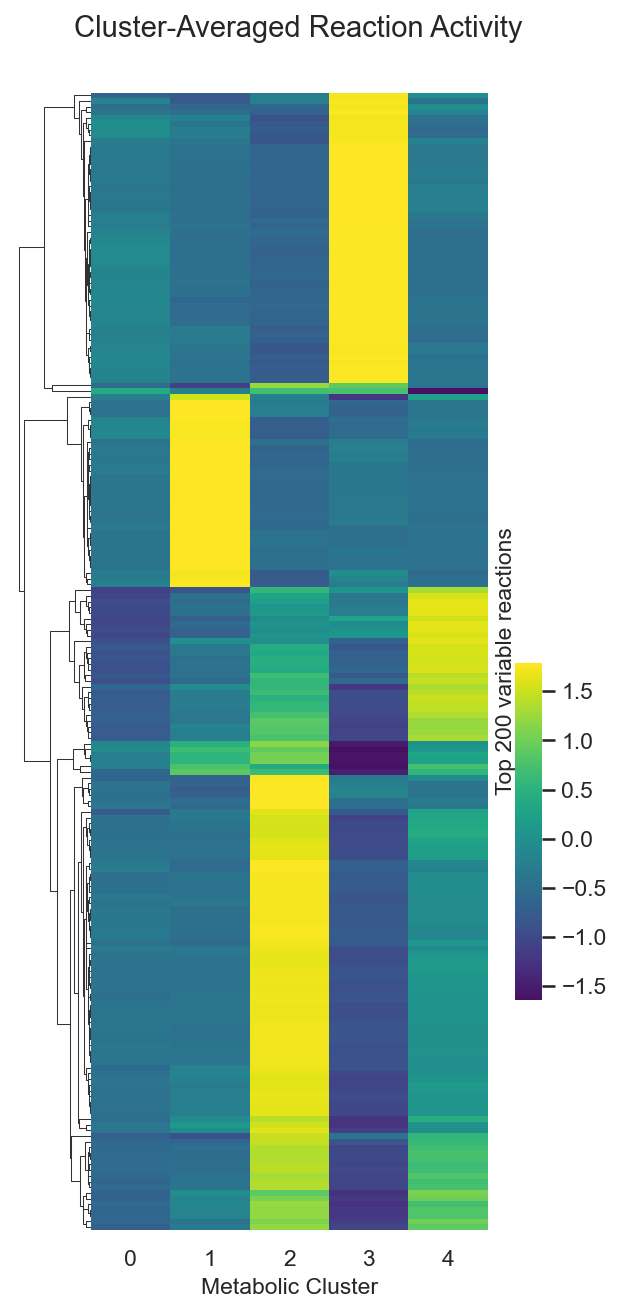

In [19]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

cluster_means = enzyme_acts_mean.groupby(cluster_series, observed=False).mean().T
cluster_means = cluster_means.loc[cluster_means.std(axis=1) > 0].copy()

top_n_rxns = 200
top_rxns = (
    cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_rxns)
    .index
)

cluster_means = cluster_means.loc[top_rxns]

plot_data = cluster_means.sub(cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(cluster_means.std(axis=1), axis=0)
plot_data.index = plot_data.index.astype(str)

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=False,
    figsize=(4.5, 9),
    dendrogram_ratio=(0.16, 0.02),
    cbar_pos=(0.82, 0.25, 0.04, 0.25),
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)
g.ax_heatmap.set_ylabel(f"Top {top_n_rxns} variable reactions", fontsize=11)
g.ax_heatmap.tick_params(axis="x", rotation=0)

g.fig.suptitle("Cluster-Averaged Reaction Activity", fontsize=14, y=0.98)

# Tighten layout manually.
g.fig.subplots_adjust(left=0.08, right=0.78, top=0.94, bottom=0.08)

# Re-apply colorbar position after subplots_adjust.
g.cax.set_position([0.82, 0.25, 0.04, 0.25])

plt.show()

### KEGG Pathway Activity Across Metabolic Clusters

Next, we aggregate reaction activity into KEGG pathway scores. Each row is a KEGG pathway and each column is a metabolic cluster. Values are average pathway activity within each cluster, z-scored across clusters.

This provides a canonical pathway-level summary of metabolic differences between clusters.

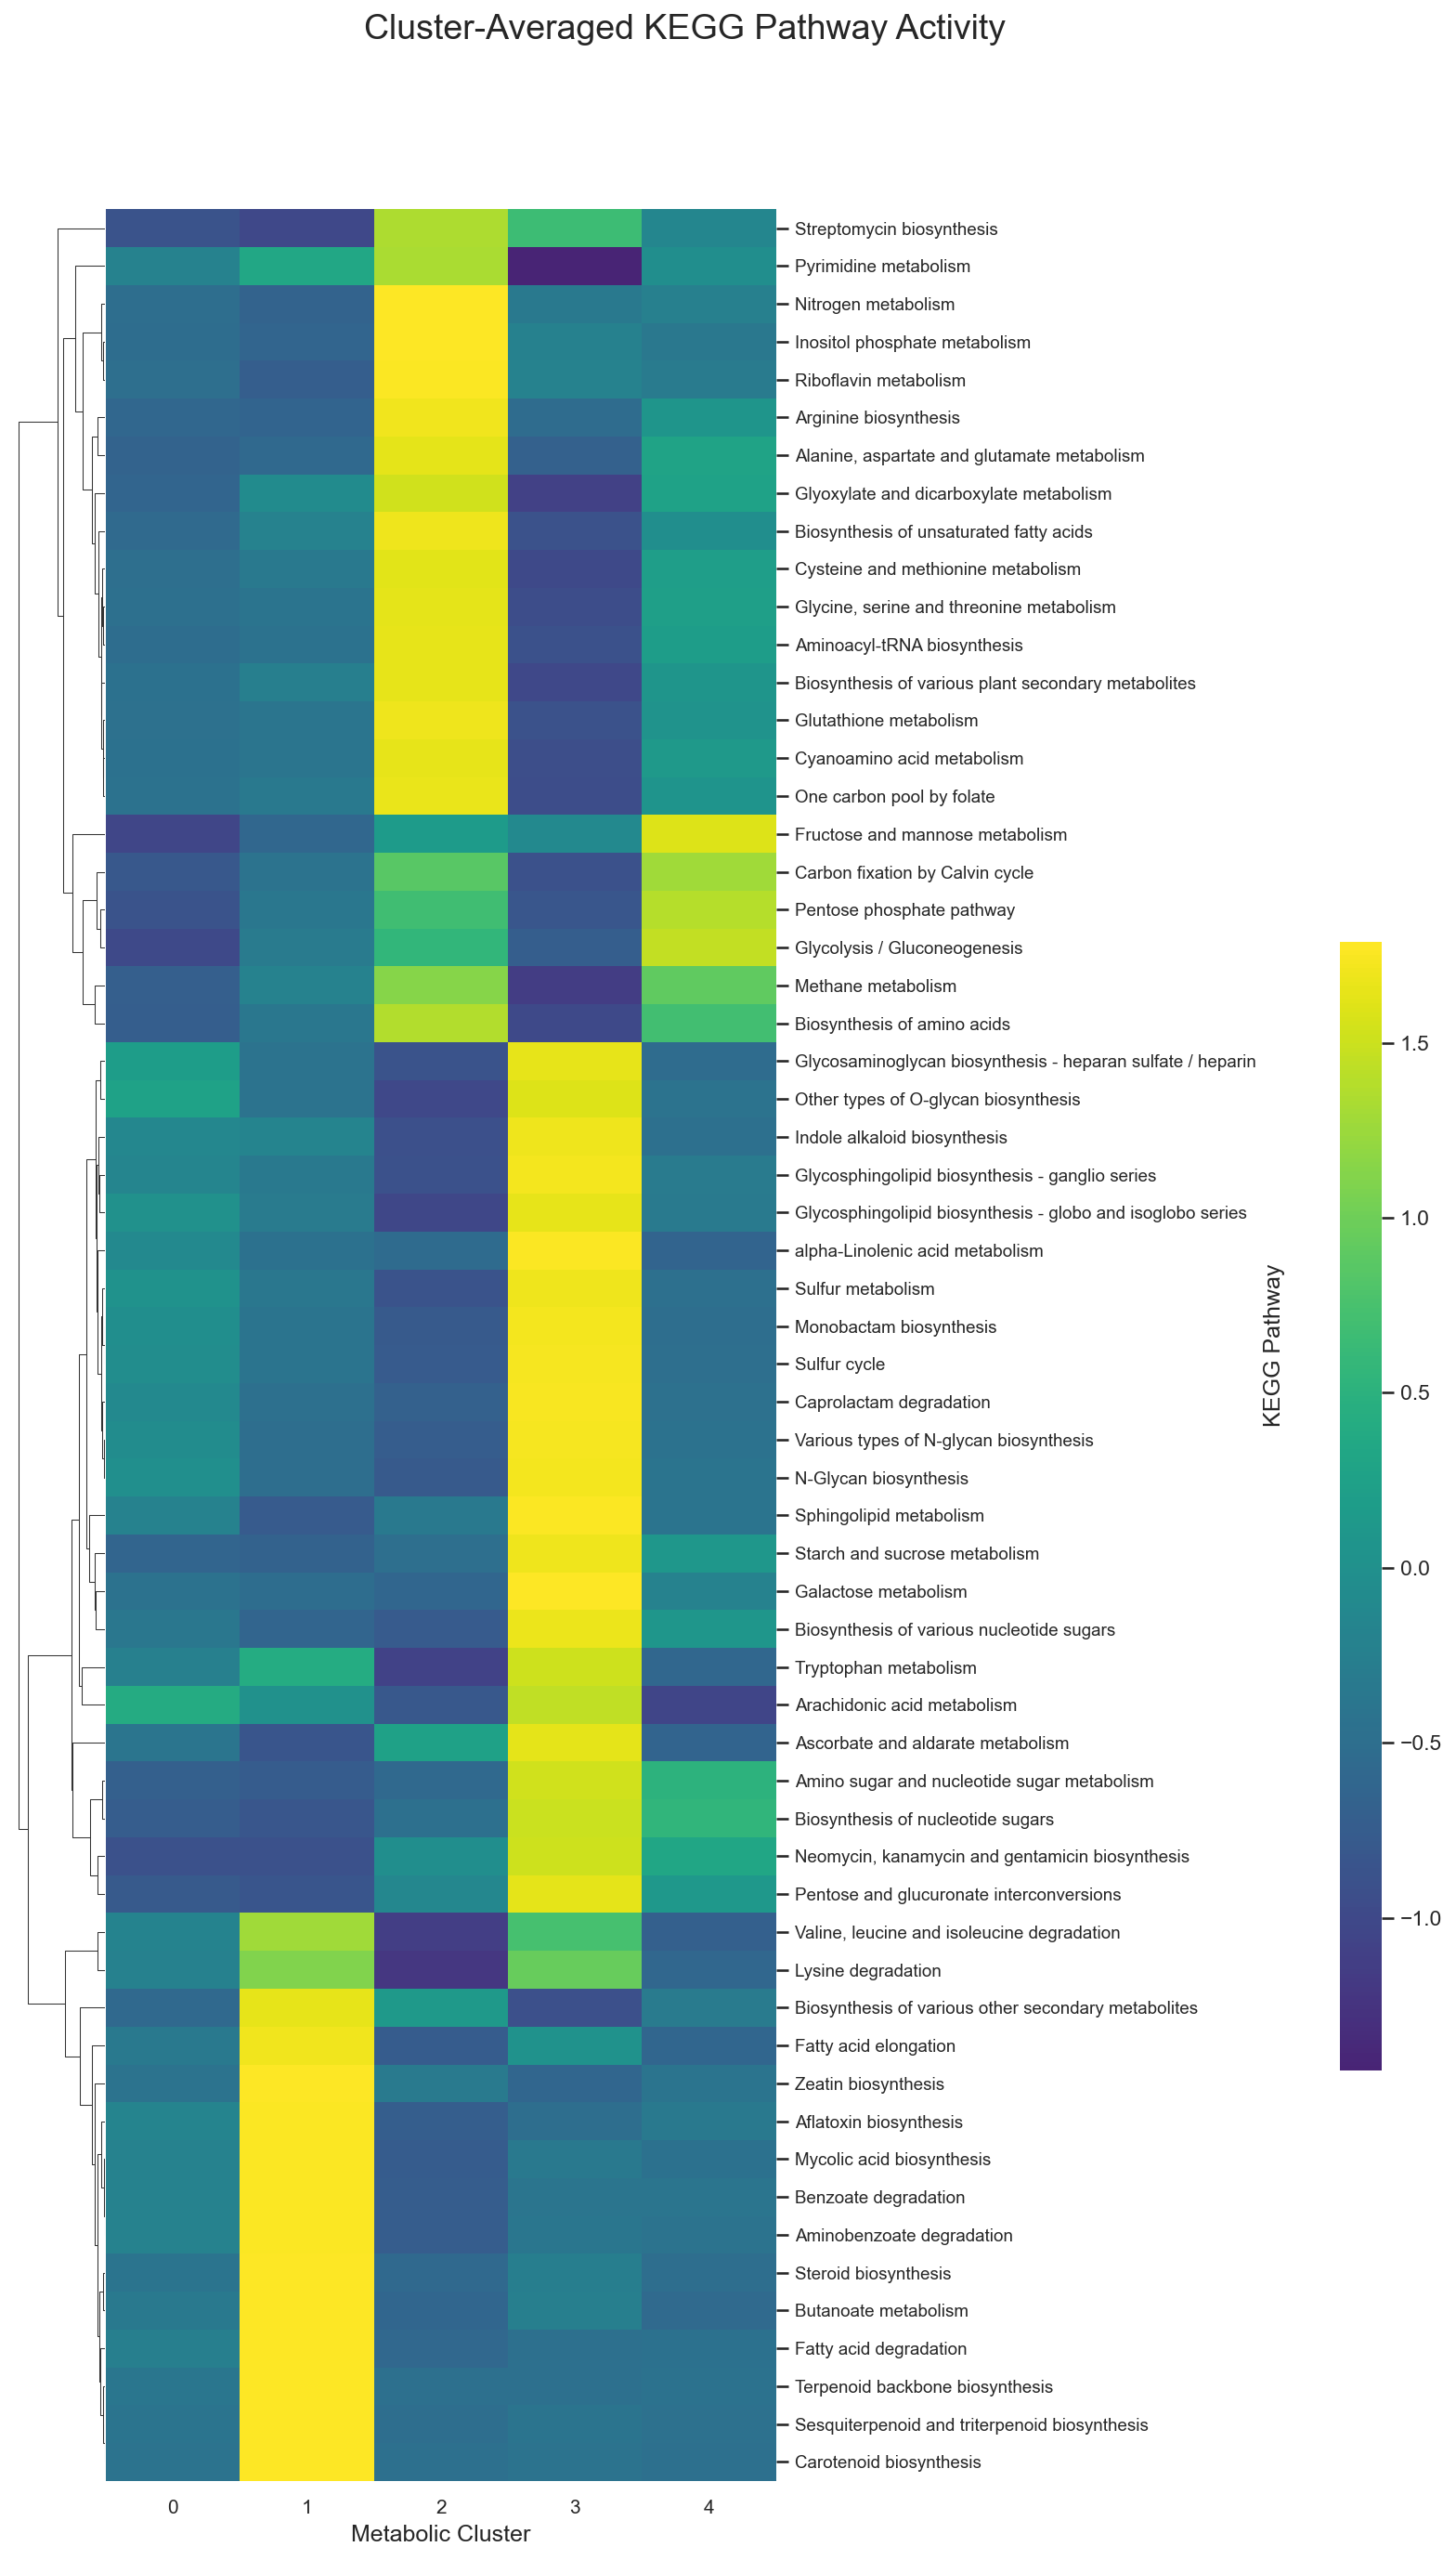

In [20]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

pathway_cluster_means = pathway_scores.groupby(cluster_series, observed=False).mean().T

exclude_pathways = {"rn01100", "rn01110", "rn01120", "rn01200"}

pathway_cluster_means = pathway_cluster_means.loc[
    ~pathway_cluster_means.index.isin(exclude_pathways)
].copy()

pathway_cluster_means = pathway_cluster_means.loc[
    pathway_cluster_means.std(axis=1) > 0
].copy()

top_n_pathways = 60

top_pathways = (
    pathway_cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_pathways)
    .index
)

pathway_cluster_means = pathway_cluster_means.loc[top_pathways]

# Z-score each pathway across clusters.
plot_data = pathway_cluster_means.sub(pathway_cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(pathway_cluster_means.std(axis=1), axis=0)

# Use pathway names as labels.
plot_data.index = [
    pathway_names.get(pathway_id, pathway_id)
    for pathway_id in plot_data.index
]

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(10, 18),
    dendrogram_ratio=(0.12, 0.05),
    cbar_pos=(0.97, 0.2, 0.03, 0.45),
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0, fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=12)
g.ax_heatmap.set_ylabel("KEGG Pathway", fontsize=12)
g.fig.suptitle("Cluster-Averaged KEGG Pathway Activity", fontsize=18, y=1.02)

plt.show()

### DDP Activity Across Metabolic Clusters

Finally, we summarize activity at the DDP level. Each row is a data-driven pathway and each column is a metabolic cluster. Values are average DDP activity within each cluster, z-scored across clusters.

DDPs provide an intermediate view between individual reactions and broad KEGG pathways as they group reactions that are connected in the metabolic graph and coordinated across cells.

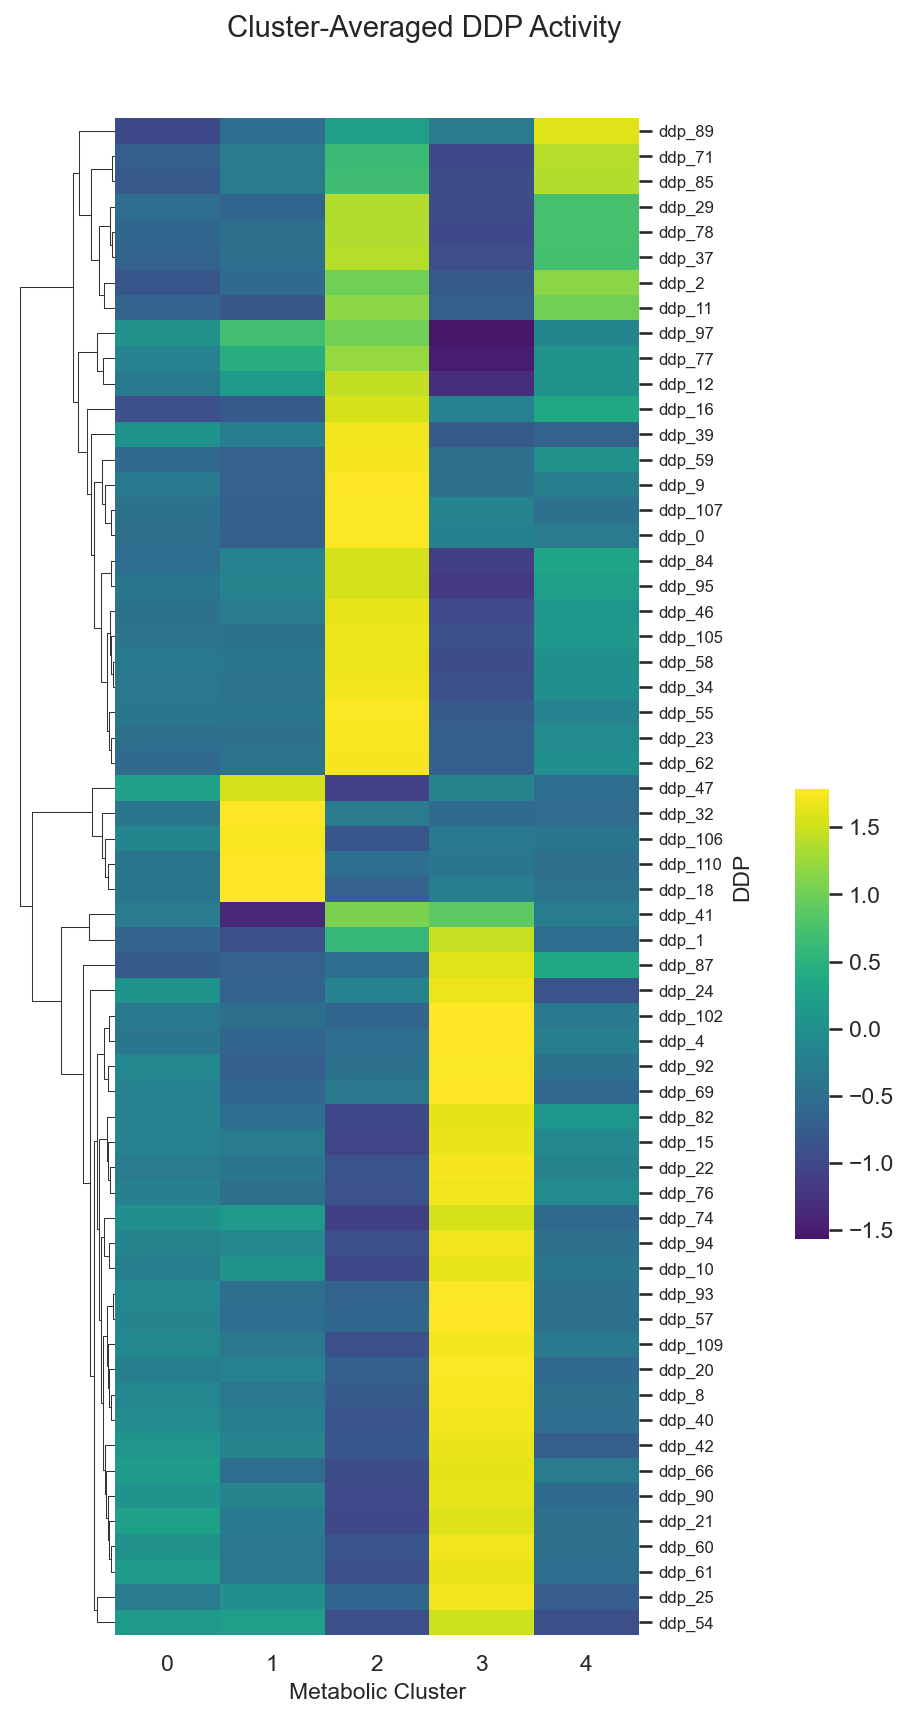

In [21]:
styled_theme(style="white", font_scale=1.0)

cluster_key = "met_leiden"
cluster_series = rna.obs[cluster_key].astype(str)

ddp_cluster_means = ddp_scores.groupby(cluster_series, observed=False).mean().T

ddp_cluster_means = ddp_cluster_means.loc[
    ddp_cluster_means.std(axis=1) > 0
].copy()

top_n_ddps = 60

top_ddps = (
    ddp_cluster_means.var(axis=1)
    .sort_values(ascending=False)
    .head(top_n_ddps)
    .index
)

ddp_cluster_means = ddp_cluster_means.loc[top_ddps]

# Z-score each DDP across clusters.
plot_data = ddp_cluster_means.sub(ddp_cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(ddp_cluster_means.std(axis=1), axis=0)

plot_data.index = plot_data.index.astype(str)

g = sns.clustermap(
    plot_data,
    cmap=HEATMAP_CMAP,
    center=0,
    row_cluster=True,
    col_cluster=False,
    xticklabels=True,
    yticklabels=True,
    figsize=(6.5, 12),
    dendrogram_ratio=(0.16, 0.02)
)

g.ax_heatmap.set_xlabel("Metabolic Cluster", fontsize=11)
g.ax_heatmap.set_ylabel("DDP", fontsize=11)
g.ax_heatmap.tick_params(axis="x", rotation=0)
g.ax_heatmap.tick_params(axis="y", labelsize=8)

g.fig.suptitle("Cluster-Averaged DDP Activity", fontsize=14, y=0.98)

g.fig.subplots_adjust(left=0.08, right=0.72, top=0.94, bottom=0.08)
g.cax.set_position([0.88, 0.30, 0.035, 0.25])

plt.show()

## Visualizing Metabolic Programs on KEGG Pathway Graphs

After summarizing reaction, KEGG pathway, and DDP activity across metabolic clusters, we can project these signals back onto metabolic pathway structure. This helps connect the matrix-level summaries to specific reactions and metabolites within known biochemical pathways.

Here we use glycolysis/gluconeogenesis as an example pathway.

### Glycolysis Reactions Colored by DDP Membership

In this plot, each edge represents a reaction in the KEGG glycolysis/gluconeogenesis pathway. We color each reaction by the DDP it belongs to.

In [22]:
# KEGG pathway plot: glycolysis reactions colored by DDP membership

pathway_id_to_plot = "rn00010"  # Glycolysis / Gluconeogenesis

# Restrict labels to reactions assigned to DDPs.
ddp_edge_labels = rxn_to_ddp.copy()

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.kegg_pathway_plot(
        pathway=pathway_id_to_plot,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        show_node_labels=True,
        node_label_fraction=0.35,
    )

fig.update_layout(
    title="Glycolysis / Gluconeogenesis: Reactions Colored by DDP Membership"
)

fig.write_image("glycolysis_ddp_plot.png", width=1200, height=800, scale=2)
fig.show()

![Glycolysis DDP plot](glycolysis_ddp_plot.png)

### Glycolysis Reactions Colored by Differential Activity

We next color the glycolysis pathway by reaction-level differential activity between two metabolic clusters.

For each reaction, we compare inferred enzyme activity in metabolic cluster 3 against metabolic cluster 2 using a Wilcoxon rank-sum test. The edge color shows Cohen’s d effect size:

- positive values indicate higher inferred reaction activity in cluster 3
- negative values indicate higher inferred reaction activity in cluster 2

In [23]:
# KEGG pathway plot colored by reaction-level differential activity

pathway_id_to_plot = "rn00010"  # Glycolysis / Gluconeogenesis

cluster_key = "met_leiden"
up_cluster = "3"
down_cluster = "2"

cluster_labels = rna.obs[cluster_key].astype(str)

up_cells = rna.obs_names[cluster_labels == up_cluster]
down_cells = rna.obs_names[cluster_labels == down_cluster]

rxn_de = mern_support.wilcoxon_test(
    enzyme_acts_mean.T,
    up_cells,
    down_cells,
)

rxn_de_info = rxn_info.join(rxn_de)

edge_color_limits = (-2, 2)

edge_values = (
    rxn_de_info["cohens_d"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=edge_color_limits[0], upper=edge_color_limits[1])
)

fig = mern_support.kegg_pathway_plot(
    pathway=pathway_id_to_plot,
    dataset=dataset,
    rna=rna,
    user_labels=edge_values,
    edge_width=4,
    edge_color_limits=edge_color_limits,
    color_scale="RdBu_r",
    show_node_labels=True,
    node_label_fraction=0.25,
)

fig.update_layout(
    title=(
        f"Glycolysis / Gluconeogenesis: Reaction Activity "
        f"Cluster {up_cluster} vs Cluster {down_cluster}"
    )
)

fig.write_image("glycolysis_cohensd_plot.png", width=1200, height=800, scale=2)
fig.show()

![Glycolysis Cohen's D plot](glycolysis_cohensd_plot.png)

### Identifying DDPs Connected to Glycolysis

A KEGG pathway shows reactions within a canonical pathway boundary. DDPs can extend this view by linking pathway reactions to other reactions that are coordinated with them across cells.

Here we identify all DDPs that contain at least one reaction annotated to glycolysis/gluconeogenesis. In the next plot, we expand beyond the KEGG glycolysis pathway by including all reactions from those glycolysis-associated DDPs.

In [24]:
# Expanded DDP-centered pathway plot for glycolysis-associated DDPs

pathway_id_to_plot = "rn00010"  # Glycolysis / Gluconeogenesis

# Reactions annotated to glycolysis.
glycolysis_rxns = set(pathway_rxns[pathway_id_to_plot])

# Find DDPs that contain at least one glycolysis reaction.
glycolysis_ddps = sorted(
    rxn_to_ddp.loc[
        rxn_to_ddp.index.intersection(glycolysis_rxns)
    ]
    .dropna()
    .unique(),
    key=lambda x: int(str(x).split("_")[-1]) if str(x).split("_")[-1].isdigit() else str(x),
)

print("Glycolysis-associated DDPs:", glycolysis_ddps)

Glycolysis-associated DDPs: ['ddp_14', 'ddp_71', 'ddp_78', 'ddp_87', 'ddp_89', 'ddp_102', 'ddp_106']


In [25]:
expanded_rxns = sorted(
    set().union(*[set(ddp_rxns[ddp]) for ddp in glycolysis_ddps])
)

print("Glycolysis reactions:", len(glycolysis_rxns))
print("Expanded DDP reactions:", len(expanded_rxns))

Glycolysis reactions: 23
Expanded DDP reactions: 114


In [26]:
# Color edges by DDP membership.
ddp_edge_labels = rxn_to_ddp.reindex(expanded_rxns)

with ddp_pathway_palette(ddp_edge_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=expanded_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=ddp_edge_labels,
        edge_width=4,
        ddp_labels=rxn_to_ddp,
        ddp_color_map=ddp_color_map_for(ddp_edge_labels),
        ddp_style="soft_contours",
        show_node_labels=True,
        node_label_fraction=0.05,
    )

fig.update_layout(
    title="Expanded Glycolysis-Associated DDP Network"
)

fig.write_image("glycolysis_ddp_expanded_plot.png", width=1200, height=800, scale=2)
fig.show()

![Glycolysis DDP Expanded plot](glycolysis_ddp_expanded_plot.png)

## Comparing Metabolic Coordination in a *Folr1* Knockout

Everything above describes wild-type (WT) embryogenesis. We now bring in a second dataset: embryos
carrying a *Folr1* knockout, which disrupts folate uptake and therefore one-carbon metabolism.

The interesting question is not only *which reactions change in mean activity*, but *which reactions
stop moving together*. A DDP is defined by coordination, so a perturbation can leave average activity
almost untouched while breaking the correlation structure that held a DDP together. The weakest-link
analysis is exactly the tool for that comparison, applied here across genotypes rather than across
metabolic clusters.

The comparison needs three ingredients:

1. **A shared cell population.** WT and *Folr1* cells were mapped onto the same reference metabolic
   clustering (`Metabolic Clustering Mapped`), so we can compare the *same* metabolic state across
   genotypes instead of comparing whole datasets.
2. **Decoded reaction activity for each genotype.** A single table is the whole knockout dataset
   here — no *Folr1* model and no *Folr1* AnnData are loaded, because the comparison is made
   entirely between reaction-activity matrices.
3. **One metabolic graph.** We reuse the WT reaction graph `met_g` built earlier so both genotypes are
   clustered over identical connectivity, and only the correlations differ.

### Loading the Knockout Reaction Activity

The wild-type activity table is already loaded; the knockout has its own,
`average_enzyme_activity.csv.gz` from the *Folr1* model directory. Both cover the same reactions in
the same order, which is what makes their correlation matrices comparable, and each table's row
index is that genotype's cell list.

Nothing below reads *Folr1* gene expression, so no *Folr1* AnnData and no *Folr1* model is loaded.

In [27]:
reference_mapped_path = f'{base_path_model}/mern_rep_{chosen_rep}/reference_mapped'

folr1_enzyme_acts_mean = pd.read_csv(f'{folr1_path_model}/average_enzyme_activity.csv.gz', index_col=0)

# `enzyme_acts_mean` is the wild-type activity loaded earlier; the knockout gets its own table.
wt_enzyme_acts_mean = enzyme_acts_mean

# Both tables must describe the same reactions in the same order, or the correlation matrices are
# not comparable and `calculate_ddp_structural_breaks` has no shared label set to work from.
assert wt_enzyme_acts_mean.columns.equals(folr1_enzyme_acts_mean.columns)

# Each table's index is that genotype's cell list, which is all the genotype annotation we need.
wt_cells = wt_enzyme_acts_mean.index
folr1_cells = folr1_enzyme_acts_mean.index
assert wt_cells.equals(rna.obs_names)
assert wt_cells.intersection(folr1_cells).empty

print('WT activity:   ', wt_enzyme_acts_mean.shape)
print('Folr1 activity:', folr1_enzyme_acts_mean.shape)

WT activity:    (62433, 1213)
Folr1 activity: (31771, 1213)


### Matching Metabolic States Across Genotypes

`Metabolic Clustering Mapped` assigns both WT and *Folr1* cells to the WT reference metabolic
clusters, so a cluster label means the same thing in both genotypes. The same reference mapping also
provides a metabolic UMAP covering both genotypes; plotting the labels in that shared space confirms
the mapping is coherent before we use it to select cells.

In [28]:
mapped_clustering = pd.read_csv(f'{reference_mapped_path}/metabolic_clustering.csv', index_col=0)
mapped_state_labels = mapped_clustering['Metabolic Clustering Mapped'].astype(str)

# The reference mapping was run over both genotypes at once, so it must cover exactly these cells.
assert set(mapped_clustering.index) == set(wt_cells) | set(folr1_cells)

# The WT object still gets the labels, since the WT plots below read them from it.
rna.obs['Metabolic Clustering Mapped'] = (
    mapped_state_labels.reindex(rna.obs_names).astype('category')
)

# The reference-mapped metabolic UMAP puts both genotypes in one space.
mapped_umap = pd.read_csv(f'{reference_mapped_path}/metabolic_umap.csv', index_col=0)

state_counts = pd.DataFrame({
    'WT': mapped_state_labels.reindex(wt_cells).value_counts(),
    'Folr1': mapped_state_labels.reindex(folr1_cells).value_counts(),
}).sort_index()
state_counts.index.name = 'Metabolic Clustering Mapped'
display(state_counts)

,WT,Folr1
Metabolic Clustering Mapped,,
0,13159.0,1624
1,12710.0,4125
2,11431.0,6807
3,9768.0,9664
4,9583.0,8903
5,5782.0,145
not_majority,NaN,503


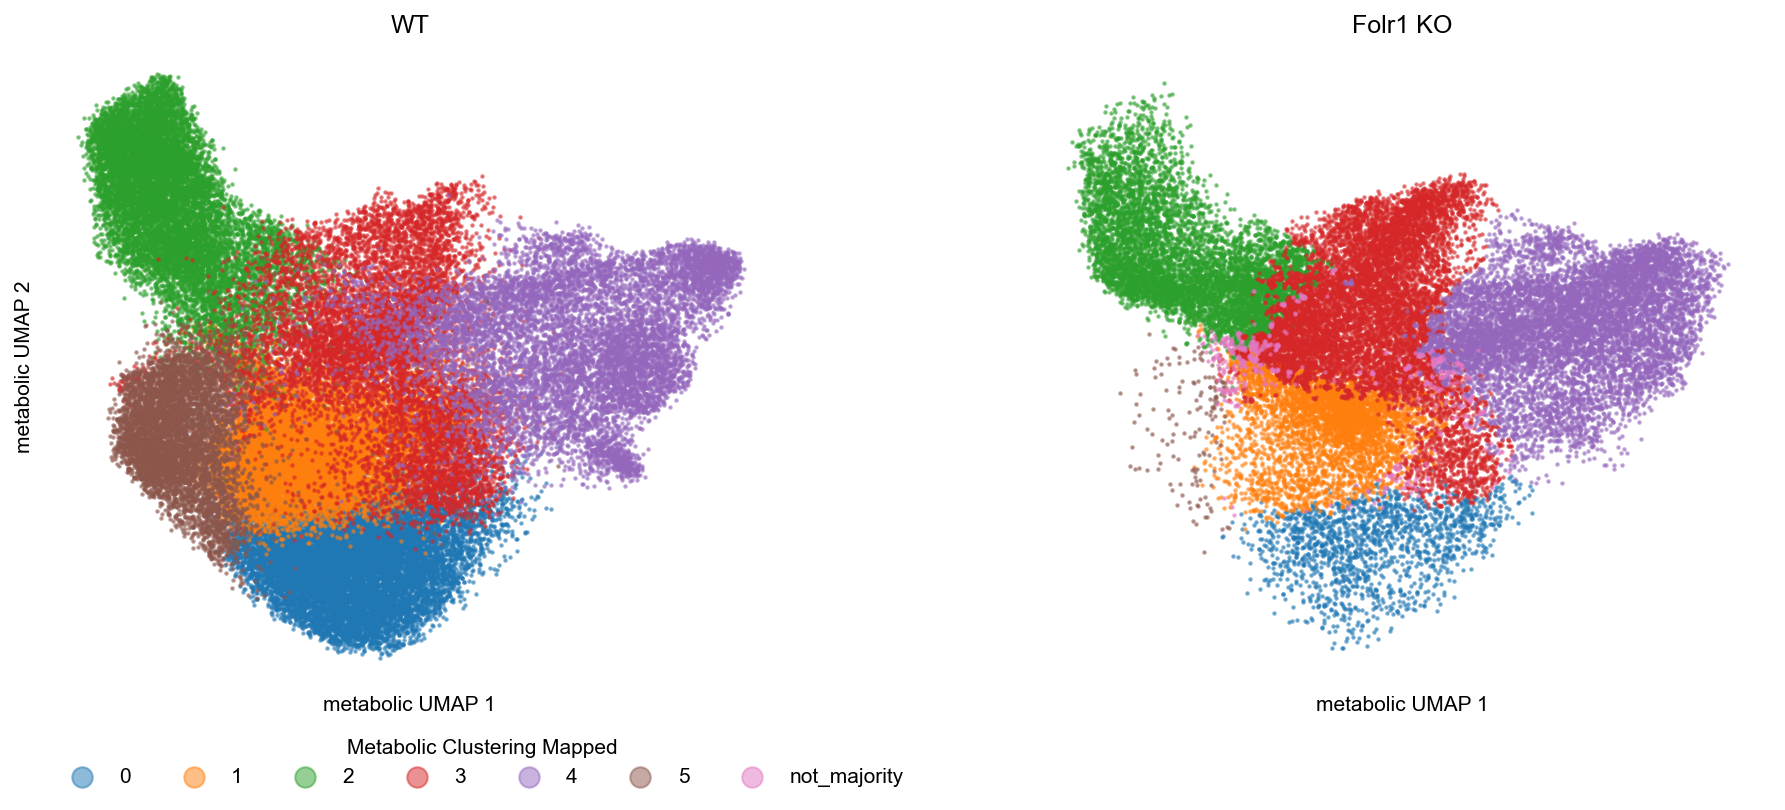

In [29]:
# Both genotypes drawn in the shared reference metabolic UMAP, colored by mapped cluster.
reset_plotting_defaults()

states = sorted(mapped_state_labels.unique())
state_colors = dict(zip(states, sns.color_palette('tab10', n_colors=len(states)).as_hex()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, (title, cells) in zip(axes, [('WT', wt_cells), ('Folr1 KO', folr1_cells)]):
    coords = mapped_umap.loc[cells]
    labels_here = mapped_state_labels.reindex(cells)
    for state in states:
        in_state = (labels_here == state).to_numpy()
        ax.scatter(
            coords.to_numpy()[in_state, 0],
            coords.to_numpy()[in_state, 1],
            s=1.5,
            alpha=0.5,
            color=state_colors[state],
            label=state if ax is axes[0] else None,
            rasterized=True,
        )
    ax.set_title(title)
    ax.set_xlabel('metabolic UMAP 1')
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].set_ylabel('metabolic UMAP 2')
axes[0].legend(
    title='Metabolic Clustering Mapped', markerscale=8,
    bbox_to_anchor=(0, -0.05), loc='upper left', ncol=len(states),
)
sns.despine(fig, left=True, bottom=True)
fig.tight_layout()
plt.show()

### Rebuilding DDPs Within One Metabolic State

Each genotype gets its own reaction-reaction correlation matrix, built from its own cells in the
shared metabolic state and its own activity table. Both are then clustered over the *WT* graph at the
same threshold, so the only thing that differs between the two hierarchies is the correlation
structure.

Because DDPs are built by thresholding correlations, they are sensitive to how reaction activity was
estimated: a noisier estimate weakens every correlation, so fewer reactions clear the cutoff and the
programs come out smaller. This is why the tutorial uses activity averaged over many decodes rather
than a single one.

In [30]:
mapped_state = '2'  # metabolic state compared across genotypes
state_min_corr = 0.7

wt_state_cells = wt_cells[mapped_state_labels.reindex(wt_cells) == mapped_state]
folr1_state_cells = folr1_cells[mapped_state_labels.reindex(folr1_cells) == mapped_state]
print(f'metabolic state {mapped_state}: {len(wt_state_cells)} WT cells, '
      f'{len(folr1_state_cells)} Folr1 cells')

# Both linkages describe the same reactions in the same order because the two decodes share their
# columns. A reaction that does not vary within the state gives NaN correlations, which
# `calculate_ddps` never merges on; we count those rather than dropping them, so the reaction set
# stays complete.
shared_rxns = wt_enzyme_acts_mean.columns
wt_state_acts = wt_enzyme_acts_mean.loc[wt_state_cells, shared_rxns]
folr1_state_acts = folr1_enzyme_acts_mean.loc[folr1_state_cells, shared_rxns]

flat = (wt_state_acts.std(axis=0) == 0) | (folr1_state_acts.std(axis=0) == 0)
print(f'{len(shared_rxns)} reactions, {int(flat.sum())} of them flat within the state '
      f'in at least one genotype')

wt_corr = wt_state_acts.corr(method='spearman')
folr1_corr = folr1_state_acts.corr(method='spearman')

wt_ddps, wt_ddp_rxns, _, wt_linkage = mern_support.calculate_ddps(
    met_g, wt_corr, min_corr=state_min_corr
)
folr1_ddps, folr1_ddp_rxns, _, folr1_linkage = mern_support.calculate_ddps(
    met_g, folr1_corr, min_corr=state_min_corr
)

print(f'WT DDPs in state {mapped_state}:    {len(wt_ddp_rxns)}')
print(f'Folr1 DDPs in state {mapped_state}: {len(folr1_ddp_rxns)}')

# The DDP holding the two folate-linked purine reactions - GAR transformylation and AIR
# carboxylation - is the one highlighted below. Find it by membership, so it survives any
# renumbering of the DDPs.
folate_rxns = ['rn:R04325 rn:R06974', 'rn:R04209']
folate_ddps = sorted(set(wt_ddps.reindex(folate_rxns).dropna()))
print('folate reactions:', {r: wt_ddps.get(r) for r in folate_rxns})
folate_ddp = folate_ddps[0] if len(folate_ddps) == 1 else None
if folate_ddp is None:
    print('the two folate reactions are not in a single WT DDP:', folate_ddps)

metabolic state 2: 11431 WT cells, 6807 Folr1 cells
1213 reactions, 0 of them flat within the state in at least one genotype
WT DDPs in state 2:    129
Folr1 DDPs in state 2: 138
folate reactions: {'rn:R04325 rn:R06974': 'ddp_44', 'rn:R04209': 'ddp_44'}


### WT DDPs Across Central Carbon and Nucleotide Metabolism

Before scoring what breaks, it helps to see what the WT programs *are*. We take every DDP that
touches glycolysis, pentose phosphate, purine, or pyrimidine metabolism and draw all of their
reactions on the reaction graph, colored by DDP membership. Each DDP is a connected, coordinated
block; the layout separates the four pathway neighborhoods, and `folate_ddp` is the thin link running
between the purine and pyrimidine lobes.

Only WT DDPs appear here. The knockout's own clustering is not used by this plot or the next one.

In [31]:
pathways_of_interest = ['rn00010', 'rn00030', 'rn00230', 'rn00240']

keep_ddps = set()
keep_rxns = set()
for rxn in shared_rxns:
    if rxn not in rxn_info.index:
        continue
    rxn_pathways = str(rxn_info.loc[rxn, 'Pathways']).split(';')
    if not set(rxn_pathways) & set(pathways_of_interest):
        continue
    keep_rxns.add(rxn)
    if rxn in wt_ddps.index and wt_ddps[rxn] is not None and not pd.isnull(wt_ddps[rxn]):
        keep_ddps.add(wt_ddps[rxn])

# Include every reaction of the DDPs these pathways belong to, not just the annotated ones.
for ddp in keep_ddps:
    keep_rxns.update(wt_ddp_rxns[ddp])

keep_rxns = sorted(keep_rxns)
print(f'{len(keep_ddps)} DDPs touch the selected pathways, spanning {len(keep_rxns)} reactions')

24 DDPs touch the selected pathways, spanning 278 reactions


In [32]:
# WT DDPs over central carbon and nucleotide metabolism, colored from the registry.
wt_labels = wt_ddps.where(wt_ddps.index.isin(keep_rxns), None)

with ddp_pathway_palette(wt_labels):
    fig = mern_support.custom_pathway_plot(
        rxns=keep_rxns,
        dataset=dataset,
        rna=rna,
        user_labels=wt_labels,
        show_node_labels=True,
        node_label_fraction=0.1,
    )
fig.update_layout(title='Selected reactions colored by WT DDP membership')
fig.show()

### Weakest-Link Analysis Across Genotypes

We now run the structural-break calculation with WT as the reference state and *Folr1* as the
comparison state. Each point is a WT DDP: the x-axis is the largest drop in its weakest cophenetic
relationship, and the y-axis the largest drop in its weakest raw reaction-pair correlation. DDPs in
the upper right lose coordination in the knockout.

Note what the knockout contributes here: its correlation matrix and its linkage, but *not* its DDP
assignment. The groups being scored are the WT DDPs throughout, which is what makes each point read
as "did this wild-type program survive the knockout". `folate_ddp` is highlighted, with the
top-ranked breaks labeled alongside it.

In [33]:
folr1_breaks = mern_support.calculate_ddp_structural_breaks(
    wt_ddps,
    wt_corr,
    wt_linkage,
    folr1_corr,
    folr1_linkage,
)

display(folr1_breaks.sort_values('min_cophenetic_drop', ascending=False).head(10))

,rank,ddp,n_reactions,n_pairs,wt_mean_corr,ko_mean_corr,mean_corr_drop,wt_min_corr,ko_min_corr,min_corr_drop,largest_corr_drop_pair,wt_mean_cophenetic_corr,ko_mean_cophenetic_corr,mean_cophenetic_drop,wt_min_cophenetic_corr,ko_min_cophenetic_corr,min_cophenetic_drop,largest_cophenetic_drop_pair,reactions
1,2,ddp_36,4,6,0.886221,0.853445,0.032775,0.803899,0.752852,0.051047,"(rn:R00945, rn:R03815)",0.876339,0.221709,0.654630,0.803899,-0.489658,1.293557,"(rn:R00945, rn:R03815)","[rn:R00945, rn:R01221, rn:R03425, rn:R03815]"
5,6,ddp_57,5,10,0.878681,0.854756,0.023925,0.768780,0.726088,0.042692,"(rn:R03313, rn:R00670)",0.843687,0.329677,0.514011,0.768780,-0.469577,1.238356,"(rn:R00667, rn:R03313)","[rn:R00667, rn:R01398, rn:R03313, rn:R00669 rn..."
0,1,ddp_53,5,10,0.894322,0.822531,0.071792,0.768165,0.678235,0.089929,"(rn:R00253 rn:R00256, rn:R03905)",0.860158,0.106422,0.753735,0.768165,-0.469577,1.237741,"(rn:R00253 rn:R00256, rn:R00575)","[rn:R00253 rn:R00256, rn:R00149 rn:R00150, rn:..."
2,3,ddp_44,4,6,0.944126,0.799947,0.144179,0.912206,0.632392,0.279814,"(rn:R04325 rn:R06974, rn:R04209)",0.938957,0.316373,0.622584,0.912206,-0.238423,1.150629,"(rn:R04325 rn:R06974, rn:R04209)","[rn:R04325 rn:R06974, rn:R04463, rn:R04208, rn..."
16,17,ddp_105,11,55,0.922245,0.925401,-0.003156,0.843996,0.753127,0.090869,"(rn:R08639, rn:R03418 rn:R03634)",0.895850,0.698779,0.197071,0.843996,-0.300736,1.144732,"(rn:R08639, rn:R00299 rn:R00303)","[rn:R08639, rn:R00875, rn:R00801, rn:R00299 rn..."
3,4,ddp_32,4,6,0.906729,0.918539,-0.011810,0.861993,0.836742,0.025251,(rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R0...,0.883142,0.340471,0.542672,0.861993,-0.267723,1.129716,(rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R0...,[rn:R00341 rn:R00345 rn:R00346 rn:R00431 rn:R0...
7,8,ddp_72,6,15,0.887061,0.897381,-0.010320,0.710825,0.708340,0.002486,"(rn:R00357, rn:R00342 rn:R00343)",0.851087,0.472422,0.378665,0.710825,-0.382838,1.093663,"(rn:R00357, rn:R00342 rn:R00343)","[rn:R00357, rn:R00342 rn:R00343, rn:R00342 rn:..."
8,9,ddp_118,20,190,0.910956,0.888511,0.022445,0.744059,0.648713,0.095347,"(rn:R08575, rn:R01600 rn:R02187 rn:R09086)",0.845514,0.507326,0.338188,0.744059,-0.300736,1.044795,"(rn:R00764 rn:R00756 rn:R00762 rn:R05805, rn:R...","[rn:R00764 rn:R00756 rn:R00762 rn:R05805, rn:R..."
4,5,ddp_29,3,3,0.750792,0.729402,0.021389,0.722751,0.621528,0.101224,"(rn:R08733, rn:R08735)",0.737175,0.202833,0.534342,0.722751,-0.087396,0.810147,"(rn:R08733, rn:R08734)","[rn:R08733, rn:R08734, rn:R08735]"
6,7,ddp_120,23,253,0.925665,0.843081,0.082583,0.705091,0.446653,0.258438,"(rn:R01334, rn:R03522)",0.874720,0.478077,0.396643,0.705091,-0.082181,0.787271,"(rn:R00585 rn:R00588, rn:R01564 rn:R01565 rn:R...","[rn:R00585 rn:R00588, rn:R01334, rn:R00465 rn:..."


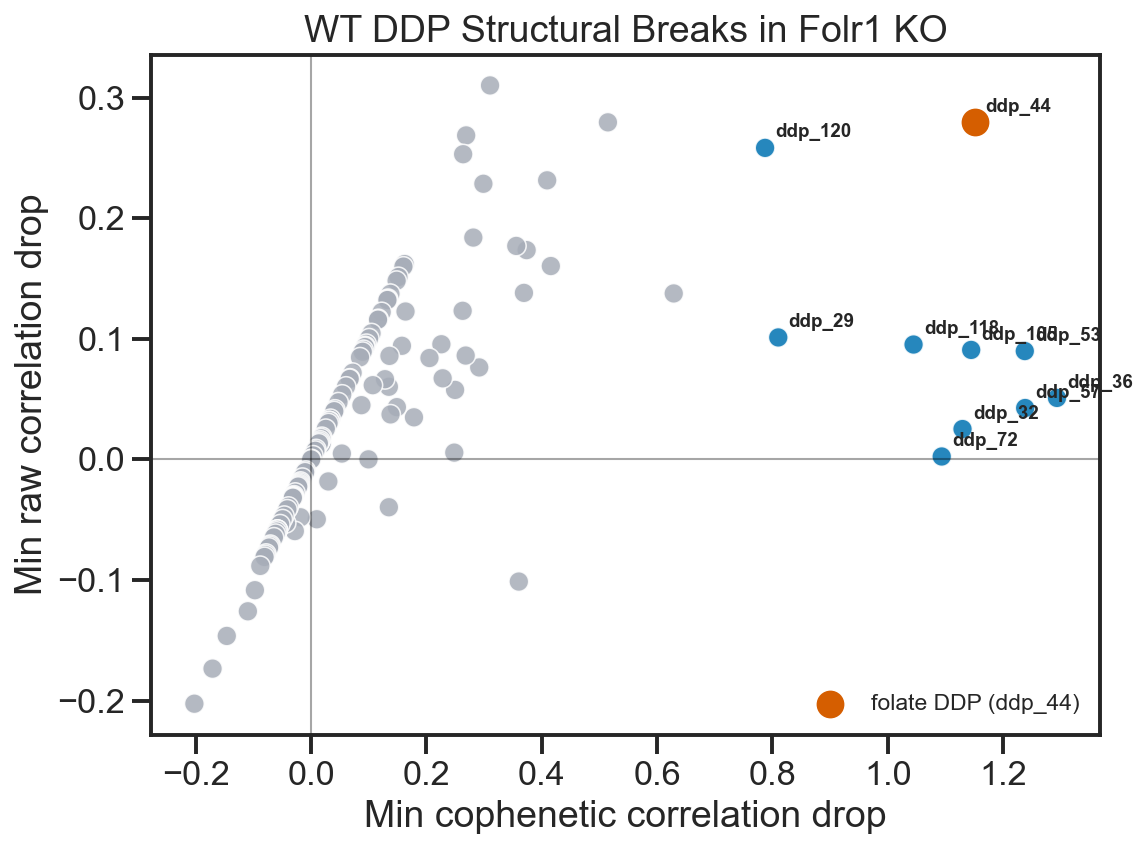

In [34]:
top_n = 10
folr1_breaks = folr1_breaks.copy()

# Rank by min_cophenetic_drop (largest drop = 1).
folr1_breaks = folr1_breaks.sort_values("min_cophenetic_drop", ascending=False)
folr1_breaks["min_cophenetic_drop_rank"] = range(1, len(folr1_breaks) + 1)
folr1_breaks["is_top"] = folr1_breaks["min_cophenetic_drop_rank"] <= top_n
folr1_breaks["is_folate"] = folr1_breaks["ddp"].astype(str).eq(str(folate_ddp))

styled_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=folr1_breaks,
    x="min_cophenetic_drop",
    y="min_corr_drop",
    hue="is_top",
    palette={True: OBSERVED_COLOR, False: BACKGROUND_COLOR},
    s=90,
    alpha=0.85,
    legend=False,
    ax=ax,
)

# Highlight the folate DDP.
folate_row = folr1_breaks.loc[folr1_breaks["is_folate"]]
ax.scatter(
    folate_row["min_cophenetic_drop"],
    folate_row["min_corr_drop"],
    color=HIGHLIGHT_COLOR,
    s=140,
    zorder=5,
    label=f"folate DDP ({folate_ddp})",
)
if not folate_row.empty:
    ax.legend(frameon=False, fontsize=11)

ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.axvline(0, color="black", linewidth=1, alpha=0.35)
ax.grid(False)

for _, row in folr1_breaks.loc[folr1_breaks["is_top"] | folr1_breaks["is_folate"]].iterrows():
    ax.annotate(
        str(row["ddp"]),
        (row["min_cophenetic_drop"], row["min_corr_drop"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )

ax.set_title("WT DDP Structural Breaks in Folr1 KO")
ax.set_xlabel("Min cophenetic correlation drop")
ax.set_ylabel("Min raw correlation drop")

fig.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig(
    "figures/DDP_structural_breaks_folr1.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()